## COMPAS - 3 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals and Regularization coefficient

In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [30]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

### Dataset and Model

In [31]:
# Setting a seed for reproducibility
seed = 42

In [32]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

In [33]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10000

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [34]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 3
results = {}

In [35]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=3,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([1/3, 1/3, 1/3]))

## MOLA

23:24:16 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
23:24:16 | DEBUG | machinemoo | Finding 1th individual minimum
23:24:16 | DEBUG | machinemoo | Finding 2th individual minimum
23:24:16 | DEBUG | machinemoo | Finding 3th individual minimum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/

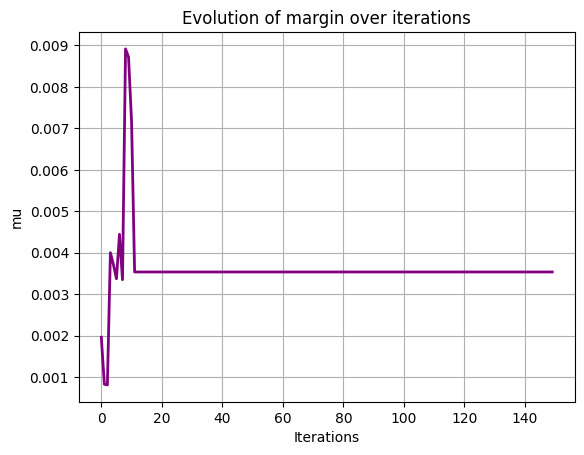

23:24:33 | INFO | machinemoo | Fit runtime: 17.39 seconds


In [36]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

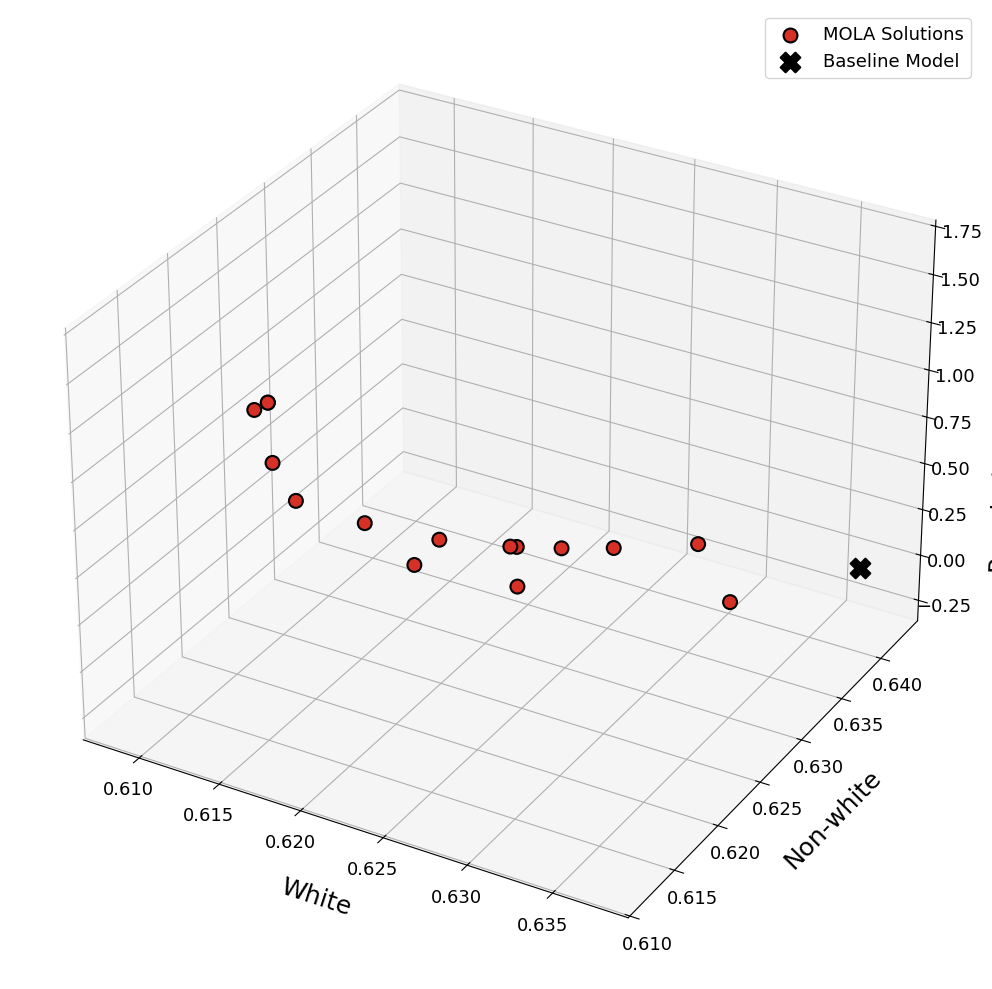

In [37]:
title = title="Loss Trade-offs for White and Non-White Person and L2 Coefficient"
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White", "Regularization Coefficient"), 
            title=title,
            point = equal.objs,
            save_path='images/3_objs_mola.pdf',
            figsize=(10,10),
            fontsize=18,
            s_factor=2
            )

23:24:34 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
23:24:34 | DEBUG | machinemoo | Finding 1th individual minimum
23:24:34 | DEBUG | machinemoo | Finding 2th individual minimum
23:24:34 | DEBUG | machinemoo | Finding 3th individual minimum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/

gradi  [-5.03496267e-09  1.78988557e-09  5.82076609e-11  2.03726813e-09
  7.13043846e-09  0.00000000e+00  7.45058060e-09 -6.60646409e-02
 -3.44730960e-03 -2.33981316e-03  8.52145255e-03  1.92976440e-03
 -5.71490219e-03 -5.71490917e-03  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00]
gradi  [ 2.49599516e-02  2.14645243e-03  4.91204497e-04 -1.12599619e-02
 -4.56051296e-03  0.00000000e+00 -2.36977870e-03  2.37778295e-08
 -8.73114914e-10 -2.44472176e-09 -2.66300049e-09  3.20142135e-10
 -7.93079380e-09 -1.86264515e-09  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00]
gradi  [ 2.49599516e-02  2.14645243e-03  4.91204497e-04 -1.12599619e-02
 -4.56051296e-03  0.00000000e+00 -2.36977870e-03  2.37778295e-08
 -8.73114914e-10 -2.44472176e-09 -2.66300049e-09  3.20142135e-10
 -7.93079380e-09 -1.86264515e-09  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 

23:24:34 | DEBUG | machinemoo | Calculated weights: [0.         0.98819414 0.01180586]
23:24:34 | DEBUG | machinemoo | Importance: 0.0019627486445085163
23:24:34 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61658481 1.17220873]
23:24:34 | DEBUG | machinemoo | Iteration 1
23:24:34 | DEBUG | machinemoo | Solutions list: [array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392,

gradi  [ 4.49171700e-02  1.53097073e-02 -3.40426574e-03 -3.70363146e-03
  3.81174404e-03  0.00000000e+00  1.16824619e-02 -1.90752244e-03
  5.91984624e-03 -7.46057229e-03  3.67997959e-03  2.30308622e-03
 -8.51287041e-09 -4.65661287e-09  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00]


23:24:35 | DEBUG | machinemoo | Calculated weights: [9.99995397e-01 4.58691062e-06 0.00000000e+00]
23:24:35 | DEBUG | machinemoo | Importance: 0.0012419780603863202
23:24:35 | DEBUG | machinemoo | Global lower bound (y*): [0.61120214 0.61658481 0.79301659]
23:24:35 | DEBUG | machinemoo | Iteration 2
23:24:35 | DEBUG | machinemoo | Solutions list: [array([0.61523724, 0.6179805 , 0.79303977]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  

...

gradi  [ 2.30822479e-07  1.44646037e-08  1.16415322e-10 -3.46626621e-08
 -1.12922862e-08  0.00000000e+00  3.25962901e-09 -4.82023247e-02
 -2.65347026e-03 -7.93127343e-04  9.50310007e-03  3.80376470e-03
  1.43382931e-06  1.43900979e-06  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00]


23:24:37 | DEBUG | machinemoo | Calculated weights: [9.99995523e-01 4.46098045e-06 0.00000000e+00]
23:24:37 | DEBUG | machinemoo | Importance: 0.0012419665048565287
23:24:37 | DEBUG | machinemoo | Global lower bound (y*): [0.61120214 0.61658481 0.79301659]
23:24:37 | DEBUG | machinemoo | Iteration 14
23:24:37 | DEBUG | machinemoo | Solutions list: [array([0.6124441 , 0.61850513, 1.17289067]), array([0.6124441 , 0.61850513, 1.17289066]), array([0.6124441 , 0.61850363, 1.17291438]), array([0.6124441 , 0.61850514, 1.17289067]), array([0.6124441 , 0.61850514, 1.17289067]), array([0.6124441 , 0.61850515, 1.17289065]), array([0.6124441 , 0.61850514, 1.17288967]), array([0.6124441 , 0.61850513, 1.17288967]), array([0.6124441 , 0.61850513, 1.17288951]), array([0.6124441 , 0.61850513, 1.1728895 ]), array([0.6124441 , 0.61850513, 1.1728894 ]), array([0.6124441 , 0.61850513, 1.17288939]), array([0.61523724, 0.6179805 , 0.79303977]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 

gradi  [ 1.99506758e-07  9.80799086e-09 -3.49245965e-10 -3.65835149e-08
 -1.39116310e-08  0.00000000e+00 -7.91624188e-09 -4.82024141e-02
 -2.65347306e-03 -7.93127809e-04  9.50309914e-03  3.80376191e-03
  1.42204226e-06  1.42946374e-06  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00]


23:24:37 | DEBUG | machinemoo | Calculated weights: [9.99995523e-01 4.46098045e-06 0.00000000e+00]
23:24:37 | DEBUG | machinemoo | Importance: 0.0012419665048573
23:24:37 | DEBUG | machinemoo | Global lower bound (y*): [0.61120214 0.61658481 0.79301659]
23:24:37 | DEBUG | machinemoo | Iteration 15
23:24:37 | DEBUG | machinemoo | Solutions list: [array([0.6124441 , 0.61850513, 1.17289067]), array([0.6124441 , 0.61850513, 1.17289067]), array([0.6124441 , 0.61850513, 1.17289066]), array([0.6124441 , 0.61850363, 1.17291438]), array([0.6124441 , 0.61850514, 1.17289067]), array([0.6124441 , 0.61850514, 1.17289067]), array([0.6124441 , 0.61850515, 1.17289065]), array([0.6124441 , 0.61850514, 1.17288967]), array([0.6124441 , 0.61850513, 1.17288967]), array([0.6124441 , 0.61850513, 1.17288951]), array([0.6124441 , 0.61850513, 1.1728895 ]), array([0.6124441 , 0.61850513, 1.1728894 ]), array([0.6124441 , 0.61850513, 1.17288939]), array([0.61523724, 0.6179805 , 0.79303977]), array([0.6124441 , 0.6

gradi  [ 1.99506758e-07  9.80799086e-09 -3.49245965e-10 -3.65835149e-08
 -1.39116310e-08  0.00000000e+00 -7.91624188e-09 -4.82024141e-02
 -2.65347306e-03 -7.93127809e-04  9.50309914e-03  3.80376191e-03
  1.42204226e-06  1.42946374e-06  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00]


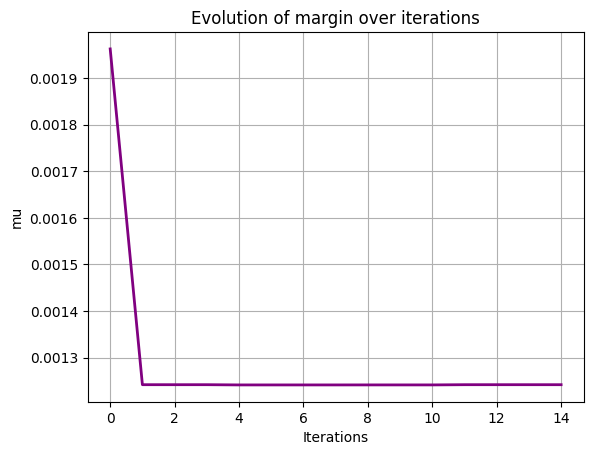

23:24:37 | INFO | machinemoo | Fit runtime: 3.68 seconds


In [38]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               #gradient=False
                               gradient=True
                               )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

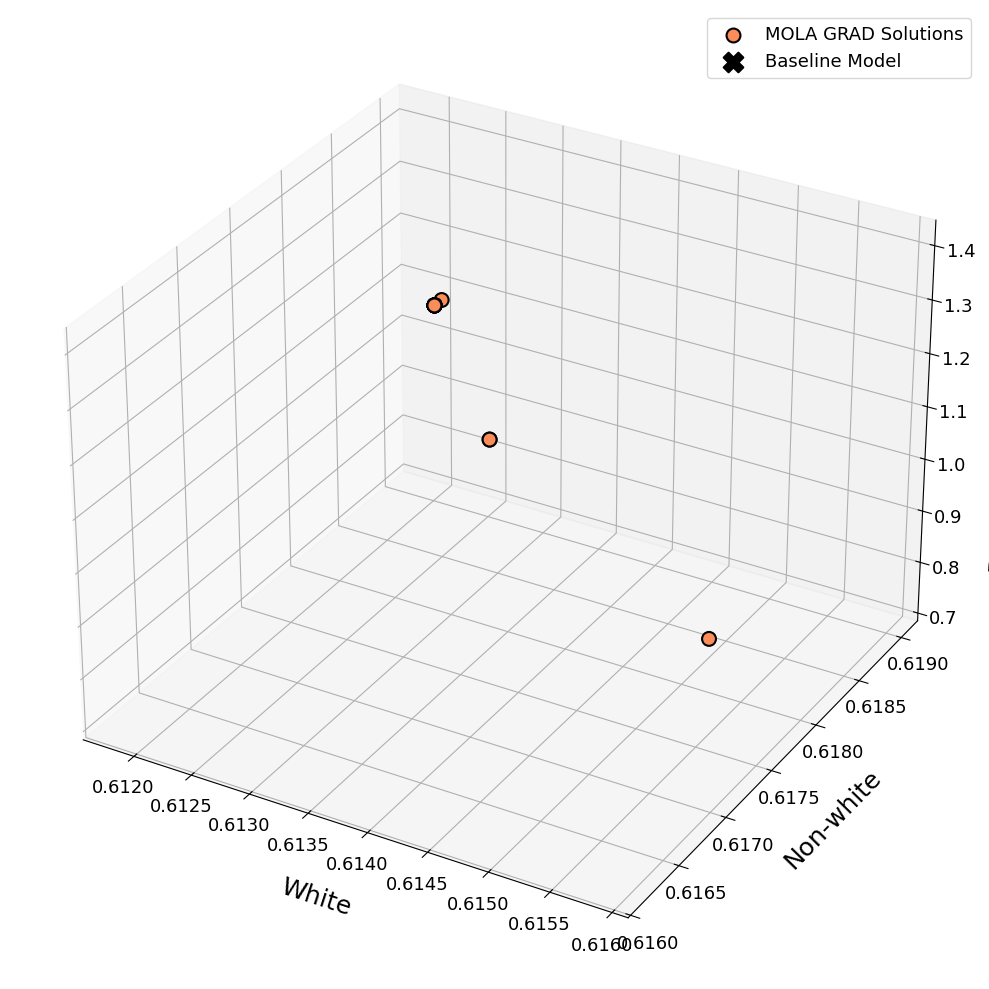

: 

In [ ]:
title = title="Loss Trade-offs for White and Non-White Person and L2 Coefficient"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            color=['#fc8d59'],
            labels=("White", "Non-White", "Regularization Coefficient"), 
            title=title,
            point = equal.objs,
            save_path='images/3_objs_mola_grad.pdf',
            figsize=(10,10),
            fontsize=18,
            s_factor=2
            )

### MONISE

In [40]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

23:24:38 | DEBUG | machinemoo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 150, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
23:24:38 | DEBUG | machinemoo | Finding 1th individual minima
23:24:38 | DEBUG | machinemoo | Finding 2th individual minima
23:24:38 | DEBUG | machinemoo | Finding 3th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


23:24:38 | DEBUG | machinemoo | 4th solution - importance: 1.0
23:24:38 | DEBUG | machinemoo | 5th solution - importance: 1.0
23:24:38 | DEBUG | machinemoo | 6th solution - importance: 1.0
23:24:38 | DEBUG | machinemoo | 7th solution - importance: 1.0
23:24:38 | DEBUG | machinemoo | 8th solution - importance: 1.0
23:24:38 | DEBUG | machinemoo | 9th solution - importance: 0.5154274975472122
23:24:38 | DEBUG | machinemoo | 10th solution - importance: 0.12874591714568845


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


23:24:38 | DEBUG | machinemoo | 11th solution - importance: 0.1286916108340204
23:24:38 | DEBUG | machinemoo | 12th solution - importance: 0.03331041147209454
23:24:39 | DEBUG | machinemoo | 13th solution - importance: 0.0328149984336095
23:24:39 | DEBUG | machinemoo | 14th solution - importance: 0.0315441557342531


...

23:24:42 | DEBUG | machinemoo | 35th solution - importance: 0.002286855221201558


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


23:24:43 | DEBUG | machinemoo | 36th solution - importance: 0.002286855221201558


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


23:24:43 | INFO | machinemoo | Best solution found.


### Ramdon Weighted Sum

In [41]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

23:24:43 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
23:24:43 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
23:24:43 | DEBUG | machinemoo | Finding 1th individual minima
23:24:43 | DEBUG | machinemoo | Finding 2th individual minima
23:24:43 | DEBUG | machinemoo | Finding 3th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_poin

In [ ]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 150
[[6.12444098e-01 6.18579757e-01 1.17220873e+00]
 [6.14505454e-01 6.16594020e-01 1.33842217e+00]
 [6.14505454e-01 6.16594020e-01 1.33842217e+00]
 [6.45905766e-01 6.47825653e-01 1.02918797e-02]
 [6.36642478e-01 6.37923179e-01 3.88934209e-02]
 [6.41444275e-01 6.41402767e-01 2.14518454e-02]
 [6.39685427e-01 6.39590237e-01 2.85420338e-02]
 [6.34943058e-01 6.35608702e-01 5.61750623e-02]
 [6.39582338e-01 6.39460194e-01 2.91444452e-02]
 [6.14941587e-01 6.18298166e-01 7.46507302e-01]
 [6.43311804e-01 6.57482849e-01 8.85028643e-03]
 [6.20204451e-01 6.26479805e-01 2.73090550e-01]
 [6.13932627e-01 6.19506630e-01 7.03927306e-01]
 [6.46496712e-01 6.46540020e-01 1.11627106e-02]
 [6.33129618e-01 6.39046162e-01 4.49495761e-02]
 [6.25717441e-01 6.30237172e-01 1.42594239e-01]
 [6.43624152e-01 6.43913229e-01 1.52728888e-02]
 [6.47231757e-01 6.44184353e-01 1.40237164e-02]
 [6.55662108e-01 6.64960988e-01 2.62629540e-03]
 [6.40411522e-01 6.40789342e-01 2.38284902e-02]
 [

In [43]:
# Supondo que `solutions` seja seu array (N x M)
solutions = results['monise']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 36
[[0.6124441  0.61857976 1.17220873]
 [0.61450545 0.61659402 1.33842217]
 [0.61450545 0.61659402 1.33842217]
 [0.61523724 0.6179805  0.79303977]
 [0.61293342 0.61708295 1.22825519]
 [0.6125568  0.61770062 1.19310628]
 [0.61358154 0.61671455 1.27696536]
 [0.61271172 0.61736018 1.2089895 ]
 [0.6132233  0.61686766 1.25092949]
 [0.61400871 0.61662339 1.30635544]
 [0.61246817 0.61810435 1.18071156]
 [0.61262596 0.61752242 1.20062379]
 [0.61250431 0.61789432 1.18647435]
 [0.61281419 0.61721372 1.21820262]
 [0.61306986 0.61696751 1.23917259]
 [0.61339384 0.61678335 1.26352746]
 [0.61378647 0.61666124 1.29124181]
 [0.61424822 0.61660099 1.32230115]
 [0.61244811 0.61833534 1.17575839]
 [0.61245603 0.61821766 1.17811817]
 [0.61258931 0.61760951 1.19675874]
 [0.61266273 0.61744698 1.20430813]
 [0.6124842  0.61799728 1.18348355]
 [0.6125285  0.61779545 1.18968333]
 [0.6127558  0.61729227 1.21303525]
 [0.61299952 0.61702327 1.23360912]
 [0.6128717  0.61714638 1.2

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

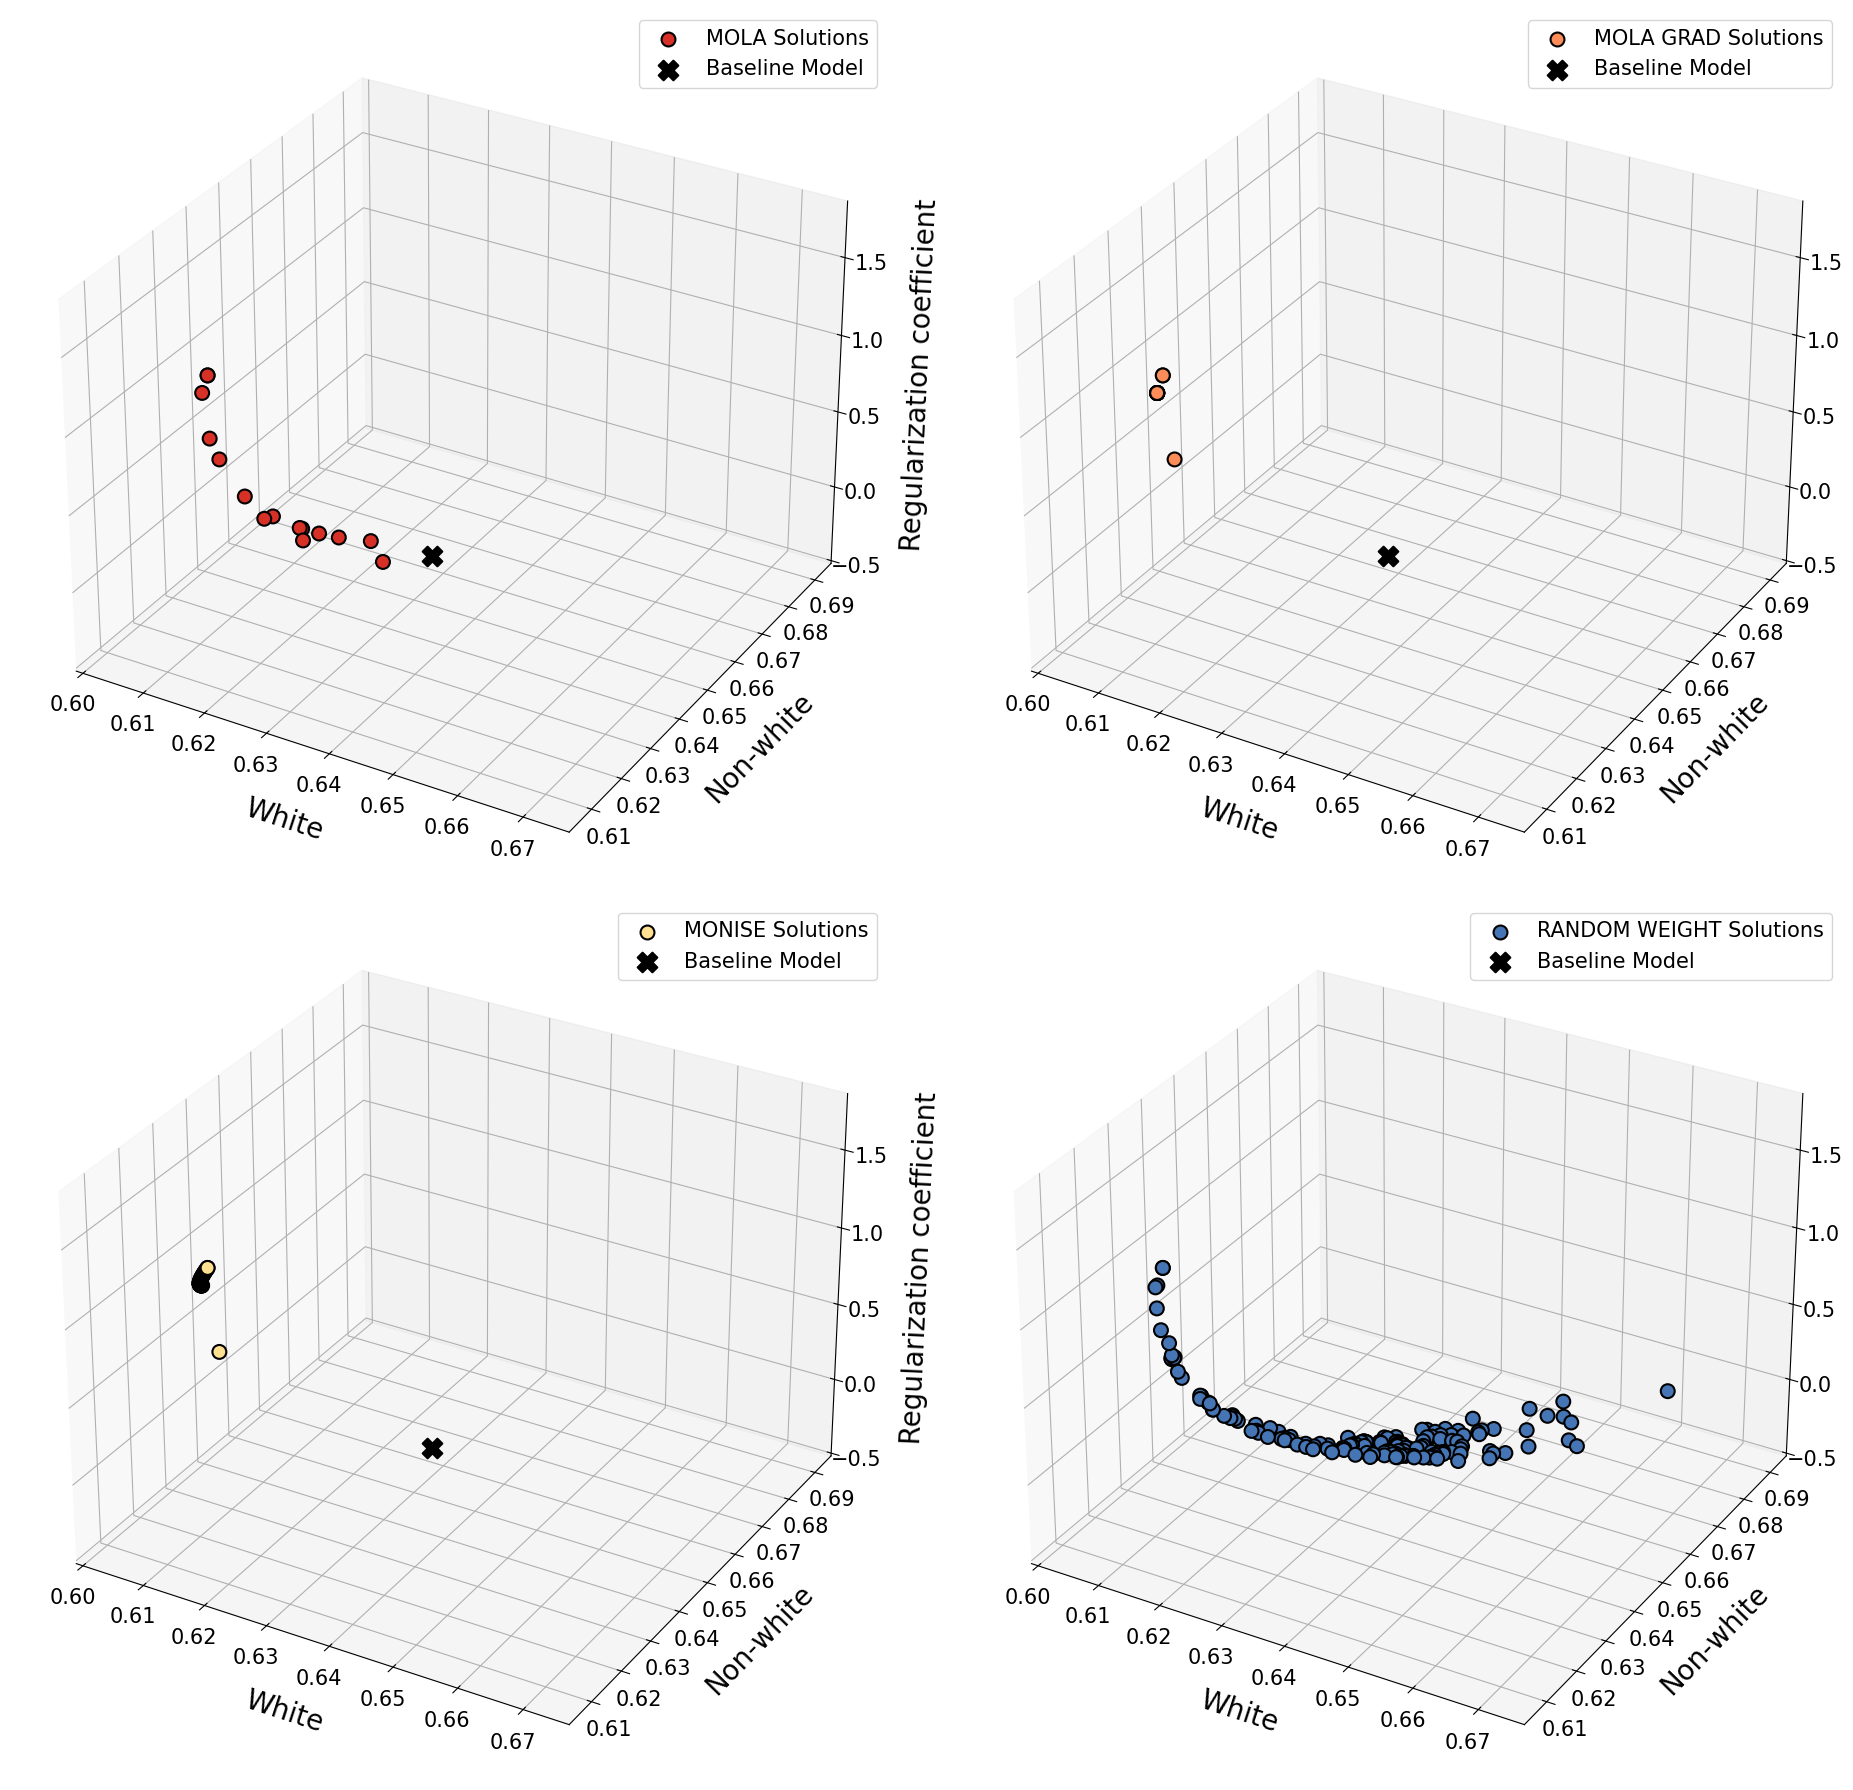

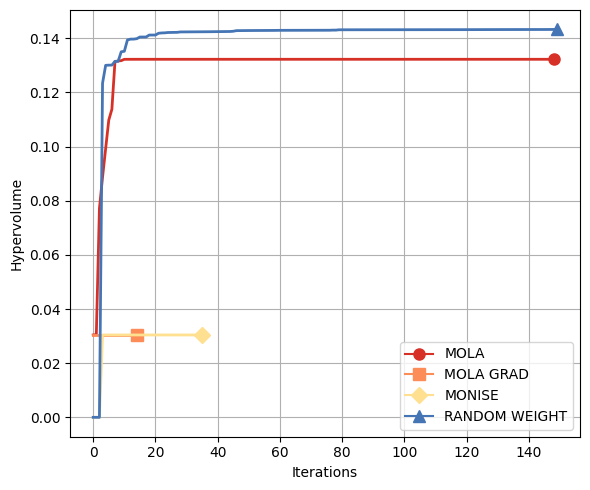

<Figure size 640x480 with 0 Axes>

In [50]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

axes_label = ["White", "Non-White", "Regularization Coefficient"]
color = ['#d73027', '#fc8d59', '#fee090', '#4575b4']
plot_pareto(methods=pareto_dict,
               labels=axes_label, 
               title=title,
               point = equal.objs,
               save_path='images/3_objs_methods.pdf',
               figsize=(10,9),
               fontsize=20,
               s_factor=2,
               color=color
               )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/3_objs_hypervolume.pdf", colors=color)

In [47]:
#Monise achou melhor solução na iteração 36
#Grad achou melhor solução na iteração 15